In [ ]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import numpy as np
import math
import os
from datetime import datetime
from library import draw_landmarks_on_image

## 1. Background

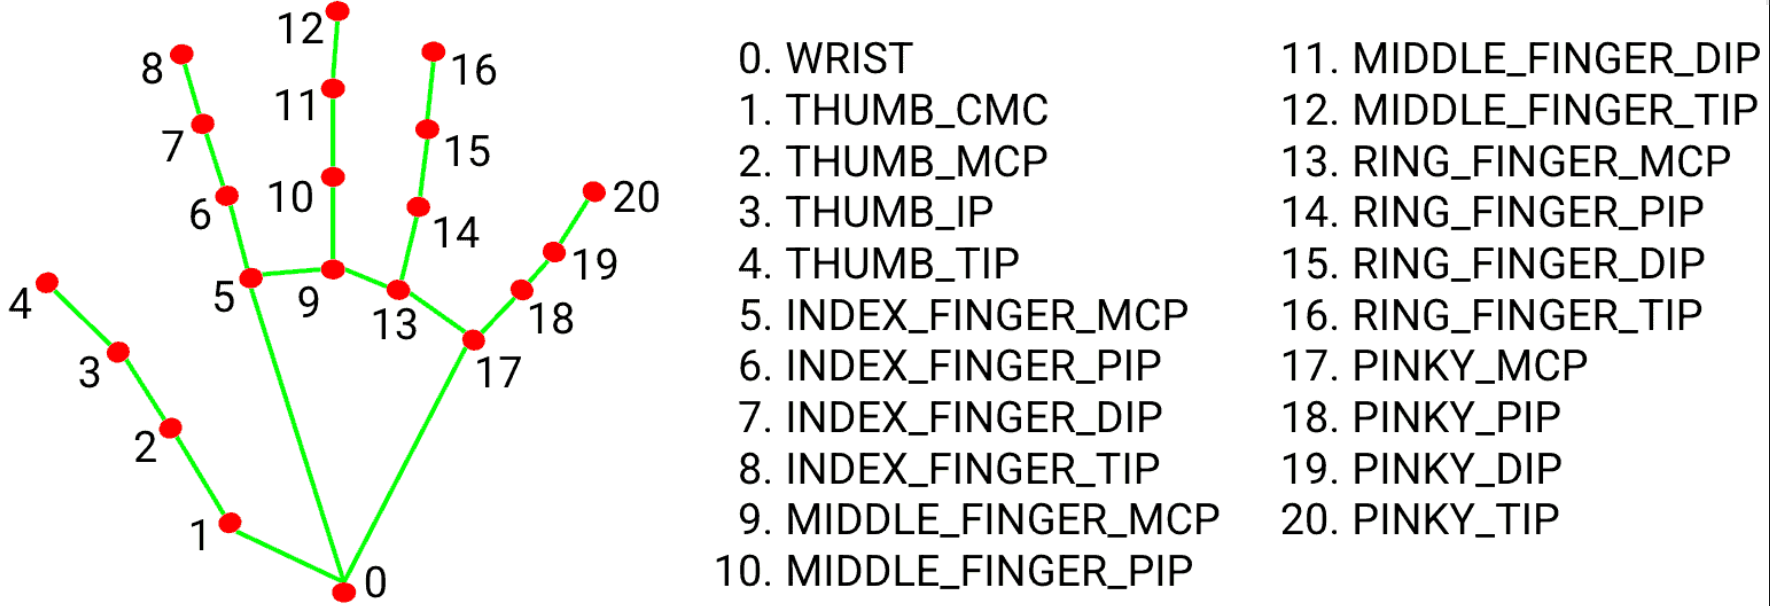

## 2. Parameter Definitions

In [ ]:
## Landmark constraints on hand
WRIST = 0

THUMB_TIP = 4

INDEX_FINGER_MCP = 5
INDEX_FINGER_PIP = 6
INDEX_FINGER_TIP = 8

MIDDLE_FINGER_MCP = 9
MIDDLE_FINGER_PIP = 10
MIDDLE_FINGER_TIP = 12

RING_FINGER_MCP = 13
RING_FINGER_PIP = 14
RING_FINGER_TIP = 16

PINKY_MCP = 17
PINKY_PIP = 18
PINKY_TIP = 20

## 3. Finger Detection Functions

Each gesture is a set of simple geometric rules applied to landmark positions from the image we saw before.

### 3.1 General Finger Up/Down Helper Functions

Before writing specific gestures, let's write two reusable helpers:

* Finger UP means TIP.y < PIP.y (the tip of the finer is higher means smaller Y on screen)

* Finger DOWN means  TIP.y > PIP.y (the tip of the finger is lower so we have a larger Y on the screen)

In these helpers there's three things we need to know:
1. What are the points? Remember, the points are the list of the 21 MediaPipe landmarks for one hand.

2. What is the tip_idx? That's the landmark index of the fingertip.

3. What is the pip_idx? This is the landmark index of the PIP (middle) knuckle.

Based on this information, we can figure out whether or not the finger is pointed up or down.

In [ ]:
def is_finger_up(points, tip_idx, pip_idx):
    return points[tip_idx].y < points[pip_idx].y

def is_finger_down(points, tip_idx, pip_idx):
    return points[tip_idx].y > points[pip_idx].y

### 3.2 Peace Sign Helper Function

When you do a peace sign, your index finger and middle finger are pointed UP while you ring and pinky are curled down. In other words, this means:

* is_finger_up(index) = True

* is_finger_up (middle) = True

* is_finger_up(ring) = False

* is_finger_up(pinky) = False

In [ ]:
def is_peace_sign(points):
    index_up = is_finger_up(points, INDEX_FINGER_TIP, INDEX_FINGER_PIP)
    middle_up = is_finger_up(points, MIDDLE_FINGER_TIP, MIDDLE_FINGER_PIP)
    ring_down = is_finger_down(points, RING_FINGER_TIP, RING_FINGER_PIP)
    pinky_down = is_finger_down(points, PINKY_TIP, PINKY_PIP)

    return index_up and middle_up and ring_down and pinky_down

#### Let's double check our functions!

In [ ]:
# We create fake landmarks so we can test WITHOUT a real camera.

class MockLM:
    """Minimal fake MediaPipe landmark for unit testing."""
    def __init__(self, x=0.5, y=0.5): self.x, self.y = x, y

def make_mock_hand():
    """21 neutral landmarks, all at y=0.5."""
    return [MockLM() for _ in range(21)]

# Test: index UP, middle UP, ring DOWN, pinky DOWN = A peace sign!
mock = make_mock_hand()
mock[INDEX_FINGER_TIP].y = 0.2 # tip above pip = UP
mock[INDEX_FINGER_PIP].y = 0.5
mock[MIDDLE_FINGER_TIP].y = 0.2 # tip above pip = UP
mock[MIDDLE_FINGER_PIP].y = 0.5
mock[RING_FINGER_TIP].y = 0.8 # tip below pip - DOWN
mock[RING_FINGER_PIP].y = 0.5
mock[PINKY_TIP].y = 0.8 # tip below pip = DOWN
mock[PINKY_PIP].y = 0.5

assert is_peace_sign(mock) == True, "Expected: True (peace sign). Actual: False (not a peace sign)"

# Sanity check: all fingers up should NOT be a peace sign (ring is up)
mock_all_up = make_mock_hand()
for idx in [INDEX_FINGER_TIP, MIDDLE_FINGER_TIP, RING_FINGER_TIP, PINKY_TIP]:
    mock_all_up[idx].y = 0.2
assert is_peace_sign(mock_all_up) == False, "Expected: False (not a peace sign). Actual: True (peace sign)"

print('Passed.')

### 3.3 Middle Finger

Middle finger is extended UP. Index, Ring, and Pinky are all curled DOWN.

* Middle finger is UP: (TIP.y < PIP.y)

* Index finger is DOWN: (TIP.y > PIP.y)

* Ring finger is DOWN: (TIP.y > PIP.y)

* Pinky is DOWN: (TIP.y > PIP.y) 

In [ ]:
def is_middle_finger(points):
    middle_up = is_finger_up(points, MIDDLE_FINGER_TIP, MIDDLE_FINGER_PIP)
    index_down = is_finger_down(points, INDEX_FINGER_TIP, INDEX_FINGER_PIP)
    ring_down = is_finger_down(points, RING_FINGER_TIP, RING_FINGER_PIP)
    pinky_down = is_finger_down(points, PINKY_TIP, PINKY_PIP)

    return middle_up and index_down and ring_down and pinky_down

#### Let's double check our functions!

In [ ]:
mock2 = make_mock_hand()
mock2[MIDDLE_FINGER_TIP].y = 0.2 # middle UP
mock2[MIDDLE_FINGER_PIP].y = 0.5
mock2[INDEX_FINGER_TIP].y = 0.8 # index DOWN
mock2[INDEX_FINGER_PIP].y = 0.5
mock2[RING_FINGER_TIP].y = 0.8 # ring DOWN
mock2[RING_FINGER_PIP].y = 0.5
mock2[PINKY_TIP].y = 0.8 # pinky DOWN
mock2[PINKY_PIP].y = 0.5

assert is_middle_finger(mock2) == True, "Expected: The Bird (True). Actual: False"

# Peace sign should NOT trigger middle finger
assert is_middle_finger(mock) == False, "Expected: Not The Bird (False). Actual: True"

print('Passed')

### 3.4 Zot Zot Zot!!

When we "Zot" we want a picture of Peter the Anteater to show up:

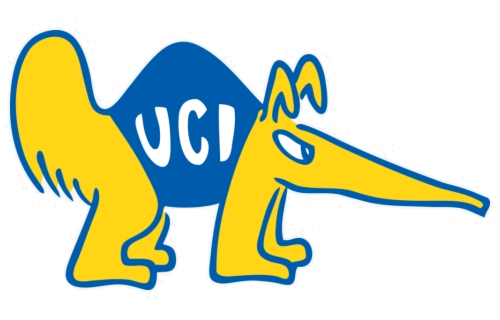

When we "Zot", we can see that:
* index finger is up
* pinky finger is up
* middle finger is down
* ring finger is down

In [ ]:
def is_zot_zot_zot(points):
    middle_down = is_finger_down(points, MIDDLE_FINGER_TIP, MIDDLE_FINGER_PIP)
    index_up = is_finger_up(points, INDEX_FINGER_TIP, INDEX_FINGER_PIP)
    ring_down = is_finger_down(points, RING_FINGER_TIP, RING_FINGER_PIP)
    pinky_up = is_finger_up(points, PINKY_TIP, PINKY_PIP)

    return middle_down and index_up and ring_down and pinky_up

### 3.5 Go, Coogs!

Do the same by yourself got UH's "Go, Coogs!"

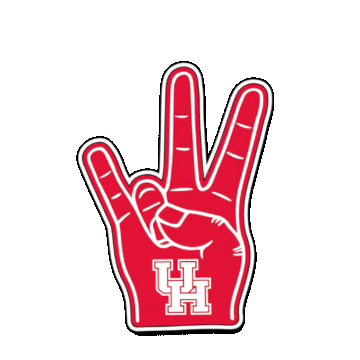

Which fingers are up? Which ones are down? Write the function by yourself and test it out. We want a picture of "Shasta" to show up.

In [ ]:
def is_go_coogs(points):
    middle_up = is_finger_up(points, MIDDLE_FINGER_TIP, MIDDLE_FINGER_PIP)
    index_up = is_finger_up(points, INDEX_FINGER_TIP, INDEX_FINGER_PIP)
    ring_down = is_finger_down(points, RING_FINGER_TIP, RING_FINGER_PIP)
    pinky_up = is_finger_up(points, PINKY_TIP, PINKY_PIP)

    return middle_up and index_up and ring_down and pinky_up


### 3.6 Pinch Gesture

When you pinch, the middle, ring, and pinky fingers are curled like a fist, while the thumb and index tips are close together (pinching).

This is different from what we did previously since the pinching gesture is about a movement of how the thumb and index tips MOVE, not about the static position they are in. So, to measure this movement, we need to measure the distance between the thumb tip (landmark 4) and the index tip (landmark 8). We will do this with Eucliedian distance:

$$D = \sqrt{(x_{1}-x_{2})^{2} + (y_{1}-y_{2})^{2}}$$

Based on this distance, we can tell zooming in and out apart:
* Zooming in: Small D means fingers close together

* Zooming out: Large D means fingers spread apart

In [ ]:
def is_fist_closed(points):
    '''
    Checks if the middle, ring, and pinky fingers are all curled.

    Used alongside pinch detection, this confirms that only the thumb and index are open (pinch posture), not a 
    full open hand.

    Note the comparison direction:
    - MCP.y < TIP.y  means the TIP is LOWER than the knuckle (curled).
    - This is correct because larger Y = lower on screen (inverted Y axis).
    '''
    middle_curled = points[MIDDLE_FINGER_MCP].y < points[MIDDLE_FINGER_TIP].y
    ring_curled = points[RING_FINGER_MCP].y < points[RING_FINGER_TIP].y
    pinky_curled = points[PINKY_MCP].y < points[PINKY_TIP].y

    return middle_curled and ring_curled and pinky_curled

def get_pinch_distance(points, image_width, image_height):
    '''
    Calculates the pixel distance between thumb tip and index finger tip.
    1. Convert normalized (0.0-1.0) landmark coordinates to pixels.
    2. Apply the Euclidean distance formula.
    '''
    # Convert normalized coords to pixel coords
    thumb_x = int(points[THUMB_TIP].x * image_width)
    thumb_y = int(points[THUMB_TIP].y * image_height)
    index_x = int(points[INDEX_FINGER_TIP].x * image_width)
    index_y = int(points[INDEX_FINGER_TIP].y * image_height)

    D = math.sqrt((thumb_x - index_x)**2 + (thumb_y - index_y)**2)
    return D

## 4. Image Effects

These functions transform the camera frame in response to detected gestures.

### 4.1 Red Filter: Response to the Middle Finger

OpenCV stores images as **BGR** (Blue, Green, Red) arrays, not RGB. This means that if we want to tint an image red, we need to follow these steps:

1. Zero out the **Blue** channel (index 0)

2. Zero out the **Green** channel (index 1)

3. Keep the **Red** channel (index 2) intact

We then blend the red mask 50/50 with the original for a semi-transparent tint instead of just a red block.

So, in this function we need to know the current frame that we see and we can output frame with a red tint.

In [ ]:
def apply_red_filter(frame):
    """
    OpenCV frames are BGR numpy arrays of shape (H, W, 3). We create a copy with Blue and Green channels zeroed out, 
    leaving only Red. Then we blend it 50/50 with the original. Then, we use the cv2.addWeighted formula:
    - output = (alpha * frame) + (beta * overlay) + gamma
    - output = (0.5  * frame) + (0.5  * red_only) + 0
    """
    red_overlay = frame.copy()
    red_overlay[:, :, 0] = 0 # zero out Blue channel (index 0)
    red_overlay[:, :, 1] = 0 # zero out Green channel (index 1)

    # Blend 50% original frame with 50% red-only overlay
    tinted = cv2.addWeighted(frame, 0.5, red_overlay, 0.5, 0)
    return tinted

### 4.1.1 Blue & Yellow Filter: Response to Zotting

Try out making a blue and yellow filter where half the image if blue and the other half is yellow!

In [ ]:
def apply_blue_and_yellow_filter(frame):
    """
    Creates an overlay where left half is blue and right half is yellow,
    then blends it with the original frame.
    """
    h, w, _ = frame.shape

    # Start with an empty overlay!
    overlay = np.zeros_like(frame)

    # Left half = blue
    overlay[:, :w//2] = (255, 0, 0) # BGR

    # Right half = yellow
    overlay[:, w//2:] = (0, 255, 255) # BGR

    # Blend overlay with original
    blended = cv2.addWeighted(frame, 0.5, overlay, 0.5, 0)

    return blended

### 4.2 Screenshot: Response to Peace Sign

When a peace sign is detected, we save the current frame as a PNG with a timestamp filename!

So, for this function we need the current frame and the directory to save the image to.

In [ ]:
def take_screenshot(frame, save_dir="screenshots"):
    os.makedirs(save_dir, exist_ok=True)

    # Timestamp format: YYYYMMDD_HHMMSS
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename  = f"screenshot_{timestamp}.png"
    filepath  = os.path.join(save_dir, filename)

    cv2.imwrite(filepath, frame) # OpenCV saves numpy array as image file
    return filepath

### 4.3 Peter the Anteater

When you Zot, Peter the anteater will pop up on your fingers!

In [ ]:
def show_peter(frame):
    peter_path = os.path.join("images", "peter.png")
    peter = cv2.imread(peter_path)
    mor_path = os.path.join("images", "morrissey.png")
    morrissey = cv2.imread(mor_path)
    h, w, _ = frame.shape
    
    peter = cv2.resize(peter, (w, h))
    morrissey = cv2.resize(morrissey, (w//10, h//5))
    
    blended = cv2.addWeighted(frame, 0.5, peter, 0.5, 0)
    blended[2*h//3-135: 2*h//3 + h//5-135, w - w//10 : w] = morrissey
    
    return blended

### 4.4 Shasta

When you do the UH sign, Shasta the cougar will pop up.

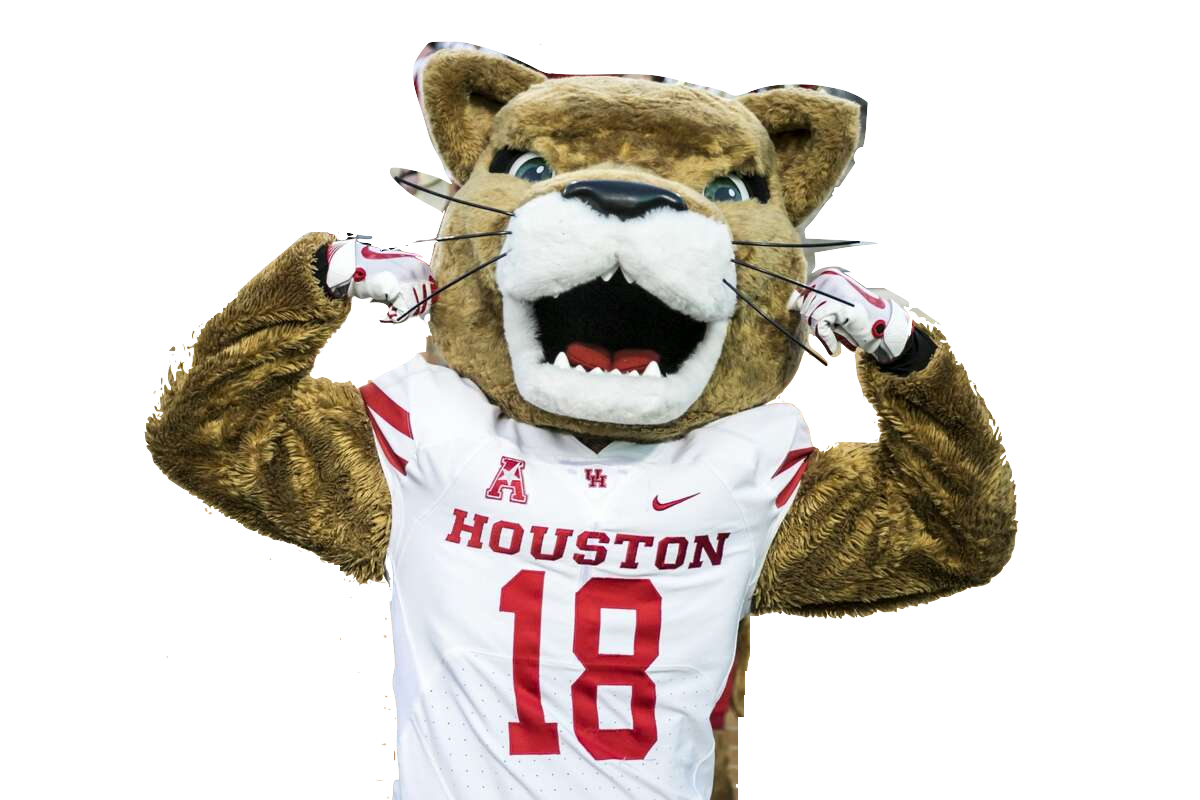

In [ ]:
def show_shasta(frame):
    shasta_path = os.path.join('images', 'uh.png')
    shasta = cv2.imread(shasta_path)
    h, w, _ = frame.shape
    
    shasta = cv2.resize(shasta, (w, h))
    blended = cv2.addWeighted(frame, 0.5, shasta, 0.5, 0)
    return blended

## 5. Zooming In!

Digital zoom works by **cropping** a smaller rectangle from the center of the frame, then **resizing** it back to the original dimensions. This makes the center content appear magnified.

So, this means that we two functions for this zooming in/out to work:

1. A function that tells us the factor that we need to zoom in by based on the pinch distance.

2. A function that applies a digital zoom to the center of the frame based on the zoom factor from earlier.

#### 5.1 Function 1: distance_to_zoom_factor

To map the pinch distance (pixels) to a zoom multiplier, we use linear interpolation. Linear interpolation is a way or using linear polynomials to construct new data points within the range of a discrete set of known data points.

Relationship is inverted: small gap = more zoom:

* pinch_distance = min_dist -> zoom = max_zoom  (fingers touching = max zoom)

* pinch_distance = max_dist -> zoom = min_zoom  (fingers wide = no zoom)

Based on this definition, the information that we need is:

* pinch_distance

* min_dist (distance that maps to maximum zoom)

* max_dist (distance that maps to no zoom)

* min_zoom (1.0 = original size)

* max_zoom (3.0 = 3x magnification)

In [ ]:
def distance_to_zoom_factor(pinch_distance, min_dist=10, max_dist=300, min_zoom=1.0, max_zoom=3.0):
    # Clamp distance to the valid range
    d = max(min_dist, min(max_dist, pinch_distance))

    # Normalize to 0->1 (0 = closest pinch, 1 = widest spread)
    t = (d - min_dist) / (max_dist - min_dist)

    # Invert: closer pinch -> higher zoom factor
    zoom = max_zoom - t * (max_zoom - min_zoom)
    return round(zoom, 2)

#### 5.2 Function 2: zoom_center

The zoom center function is how we artificially induce zooming.

The steps:
1. Compute a crop rectangle centered in the frame.
    * crop_size = original_size / zoom_factor
    * (Larger zoom_factor → smaller crop → more magnification)
2. Crop that region from the frame.
3. Resize (upscale) back to original dimensions.

Based on the frame and zoom_factor, we can return the frame with an artificially zoomed center.

In [ ]:
def zoom_center(frame, zoom_factor):
    if zoom_factor <= 1.0:
        return frame  # nothing to do

    h, w = frame.shape[:2]

    # Crop dimensions (smaller = more zoomed)
    crop_h = int(h/zoom_factor)
    crop_w = int(w/zoom_factor)

    # Center of the frame
    cy, cx = h//2, w//2

    # Crop boundaries
    y1, y2 = cy - crop_h // 2, cy + crop_h // 2
    x1, x2 = cx - crop_w // 2, cx + crop_w // 2

    # Crop, then resize back to original dimensions
    cropped = frame[y1:y2, x1:x2]
    zoomed = cv2.resize(cropped, (w, h), interpolation=cv2.INTER_LINEAR)
    return zoomed

#### Let's make sure that the pinch distance makes sense in correlation with the zoom factor 

In [ ]:
for d in [50, 75, 100, 150, 200, 250, 300]:
    zf  = distance_to_zoom_factor(d)
    print(f"D = {d}px ----> {zf}x Zoom")

## 6. Main Loop

Now we need to wire all the pieces we have made together into a live camera application!

### 6.1 The Flow

So, every time we have the camera running, we get a frame.

For each frame:

1. cap.read() = raw BGR frame from webcam
2. cv2.flip() = mirror it (selfie-style)
3. MediaPipe = detect hand landmarks
4. Check each gesture function to see what gesture we are doing and do the appropriate effect/action:
    * peace -> take_screenshot()
    * middle -> toggle red filter
    * pinch -> update zoom_factor
5. Effects = apply_red_filter() or zoom_center()
6. HUD = draw status overlay
7. imshow() = display result

#### 6.1.1 Why we need a "cooldown" timer?

At 30 fps, holding a gesture for 1 second triggers ~30 frames. Without a cooldown, the peace sign would save 30 screenshots in one second! The cooldown counter lets us fire the action once, then ignore the gesture for ~1.5 seconds.

In [ ]:
def draw_hud(frame, gesture_name, zoom_factor, red_active):
    """
    Draws a Heads-Up Display (HUD) overlay on the video frame.

    Which shows us the current gesture, zoom level, red filter status, and a controls reminder at the bottom.

    Arguments:
        frame: numpy array — current video frame
        gesture_name: string — name of the detected gesture
        zoom_factor: float  — current zoom level
        red_active: bool   — whether the red filter is on

    Returns:
        The frame with HUD drawn on it
    """

    # Gesture label
    cv2.putText(frame, f"Gesture: {gesture_name}", (12, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (255, 255, 255), 2)

    # Zoom level (in green)
    cv2.putText(frame, f"Zoom: {round(zoom_factor, 1)}x", (12, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (80, 255, 80), 2)

    # Red filter status
    if red_active:
        cv2.putText(frame, "[RED FILTER ON]", (frame.shape[1] - 240, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

    # Controls reminder at the bottom
    hint = "Q=Quit; Peace=Screenshot; Pinch=Zoom; MidFinger=Red"
    cv2.putText(frame, hint, (8, frame.shape[0] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.42, (180, 180, 180), 1)

    return frame

In [ ]:
def run_gesture_app():
    # Application state values
    zoom_factor = 1.0 # 1.0 = no zoom, 3.0 = 3x magnification
    red_filter = False # toggled by middle finger gesture
    cooldown = 0 # frames remaining before next gesture fires

    # Initialize MediaPipe Hands
    base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')
    options = vision.HandLandmarkerOptions(base_options=base_options, num_hands=2)
    detector = vision.HandLandmarker.create_from_options(options)

    # Open webcam
    cap = cv2.VideoCapture(0) # 0 = first/default camera, usually laptop webcam

    if not cap.isOpened():
        print("Could not open webcam.")
        return

    # Main frame loop!
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Failed to read from camera.")
            break

        # Mirror the frame since it feels natural for a front-facing camera
        frame = cv2.flip(frame, 1)
        h, w = frame.shape[:2]

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)

        results = detector.detect(mp_image)

        # Decrement cooldown each frame
        cooldown = max(0, cooldown - 1)
        gesture_name = "None"

        # Gesture detection
        if results.hand_landmarks:
            for hand_lms in results.hand_landmarks:
                annotated = draw_landmarks_on_image(mp_image.numpy_view(), results)
                frame = cv2.cvtColor(annotated, cv2.COLOR_RGB2BGR)
                pts = hand_lms # shorthand for the landmark list

                # Priority 1: Middle finger
                if is_middle_finger(pts):
                    gesture_name = "Middle Finger"
                    if cooldown == 0:
                        red_filter = not red_filter
                        cooldown = 30
                        print(f"Red filter: {'ON' if red_filter else 'OFF'}")

                # Priority 2: Peace sign
                elif is_peace_sign(pts):
                    gesture_name = "Peace Sign"
                    if cooldown == 0:
                        take_screenshot(frame)
                        cooldown = 45 # 1.5 seconds cooldown

                # Priority 3: Pinch
                elif is_fist_closed(pts):
                    D = get_pinch_distance(pts, w, h)
                    gesture_name = f"Pinch ({round(D, 2)}px)"
                    if 50 <= D <= 300:
                        zoom_factor = distance_to_zoom_factor(D)

                # Priority 4: Zot, Zot, Zot
                elif is_zot_zot_zot(pts):
                    gesture_name = 'Zot, Zot, Zot!'
                    frame = show_peter(frame)
                    frame = apply_blue_and_yellow_filter(frame)
                    cooldown = 30

                elif is_go_coogs(pts):
                    gesture_name = 'Go, Coogs!'
                    frame = show_shasta(frame)
                    cooldown = 30

                else:
                    # No recognized gesture means we gradually reset zoom
                    zoom_factor = max(1.0, zoom_factor - 0.03)

        else:
            # No hand visible — gradually reset zoom
            zoom_factor = max(1.0, zoom_factor - 0.03)

        # Apply effects

        # Effect 1: Red tint
        if red_filter:
            frame = apply_red_filter(frame)

        # Effect 3: Digital zoom
        frame = zoom_center(frame, zoom_factor)

        # Effect 4: HUD overlay (always drawn last, on top)
        frame = draw_hud(frame, gesture_name, zoom_factor, red_filter)

        # Display
        cv2.imshow("AI@UCI - CV Project S26: Press [q] to quit", frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    # Cleanup
    cap.release()
    detector.close()
    cv2.destroyAllWindows()
    for _ in range(5):
        cv2.waitKey(1)
    print("Camera released and windows closed successfully")

In [ ]:
run_gesture_app()